# 🎬 Netflix 콘텐츠 등급 분류 — 1-Pager
> **Netflix Movies & TV Shows | 다중 분류 | 데이터사이언스실무 Project 2**  
> Kaggle Dataset: [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)

---

In [3]:
# ══════════════════════════════════════════
#  한글 폰트 설정
# ══════════════════════════════════════════
# [Colab / Google Drive 환경에서 사용]
# import subprocess
# subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
# import matplotlib.font_manager as fm
# font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
# fm.fontManager.addfont(font_path)
# plt.rcParams['font.family'] = 'NanumGothic'

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

print('✅ 기본 설정 완료')

✅ 기본 설정 완료


---
## 📌 Section 1 — 문제 정의

---

### 🔷 [비즈니스 문제]

> **"제목·줄거리·장르 텍스트만으로 콘텐츠 연령 등급(rating)을 자동 예측할 수 있는가?"**  
> → 넷플릭스가 신규 콘텐츠 온보딩 시 등급 심사 비용을 절감하고, 국가별 규제 대응 속도를 높이기 위한 의사결정 자동화 문제.

### 왜 이 문제가 중요한가?

| 관점 | 설명 |
|------|------|
| **규제 리스크** | 국가별 콘텐츠 등급 기준이 상이 — 미분류 콘텐츠 노출 시 규제 제재 가능 |
| **사용자 경험** | 부적절 등급 노출(예: 아동에게 TV-MA) → 구독 해지·신뢰 손실 |
| **운영 효율** | 수동 등급 분류에 소요되는 인력·시간 비용 자동화 가능 |
| **글로벌 확장** | 인도·한국·스페인 등 비영어권 콘텐츠 급증 → 자동화 필요성 증가 |

### 본인 직무/관심사와의 연결

NLP와 추천 시스템에 관심이 있으며, 텍스트 기반 다중 분류는  
콘텐츠 플랫폼·미디어 도메인에서 가장 실용적으로 적용되는 문제 유형이다.  
EDA만으로도 '한국 콘텐츠 급증', '인도 Teen 등급 편중' 등 풍부한 인사이트를 도출할 수 있어  
분석 스토리텔링 역량을 함께 키울 수 있다.

### 성공 기준 (평가 메트릭 & 목표 수준)

| 메트릭 | 목표 수준 | 근거 |
|--------|-----------|------|
| **Macro F1-Score** | ≥ 0.65 | 클래스 불균형 하에서 소수 등급도 공정 평가 |
| **Weighted Recall** | ≥ 0.72 | 성인 콘텐츠 오분류(FN)의 비용이 높음 |
| **ROC-AUC (OvR)** | ≥ 0.85 | 다중 클래스 판별력 종합 |
| **PR-AUC (소수 클래스)** | ≥ 0.50 | NR·UR·NC-17 등 희귀 등급 탐지력 |

> ⚠️ **함정 주의**: 정확도(Accuracy)만 보면 속는다.  
> 최빈 클래스(TV-MA, 36.4%)만 예측해도 Accuracy ≈ 36% — 불균형 데이터는 반드시 Precision/Recall/F1로 평가해야 한다.

---
## 📊 Section 2 — 데이터 탐색

---

### 🔷 [데이터 & 클래스 분포]

In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./netflix_titles.csv')
print('▶ Shape:', df.shape)
print('▶ Columns:', df.columns.tolist())

▶ Shape: (8807, 12)
▶ Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [8]:
# 데이터 타입 & 결측치 현황
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [9]:
# 결측치 요약
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})
missing_df[missing_df['결측 수'] > 0].sort_values('결측 비율(%)', ascending=False)

,결측 수,결측 비율(%)
director,2634,29.9
cast,825,9.4
country,831,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


### 주요 컬럼 설명

| 컬럼 | 타입 | 설명 | 결측치 |
|------|------|------|--------|
| `show_id` | object | 고유 ID | 0 |
| `type` | object | Movie / TV Show | 0 |
| `title` | object | 콘텐츠 제목 | 0 |
| `director` | object | 감독명 | **29.9%** |
| `cast` | object | 출연진 | 9.4% |
| `country` | object | 제작 국가 (복수 가능) | 9.4% |
| `date_added` | object | 넷플릭스 등록일 | 0.1% |
| `release_year` | int64 | 출시 연도 | 0 |
| `rating` | object | **🎯 타깃 변수** — 연령 등급 | 0.05% |
| `duration` | object | 상영 시간 / 시즌 수 | 0.03% |
| `listed_in` | object | 장르 태그 (복수 가능) | 0 |
| `description` | object | 줄거리 요약 | 0 |

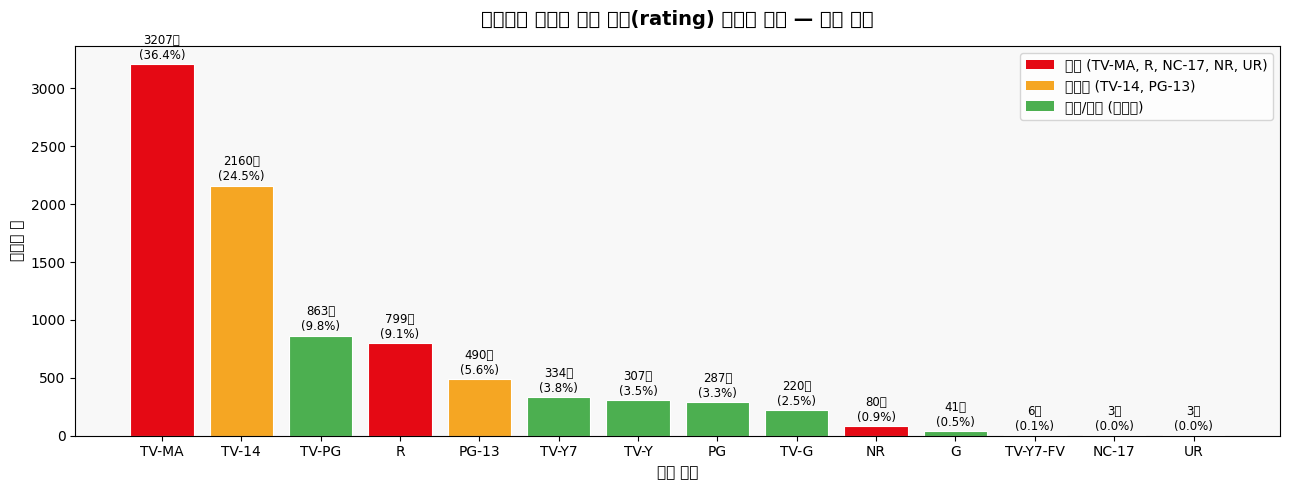


📌 클래스 불균형 현황
  - 최대 클래스: TV-MA = 3207건 (36.4%)
  - 최소 클래스: NC-17 = 3건 (0.03%)
  - 불균형 비율 (최대/최소): 1069:1
  → 심각한 불균형 데이터 — class_weight + SMOTE + Calibration 전략 필요


In [10]:
# ─── 시각화 1: 타깃 변수(rating) 클래스 분포 ───
valid_ratings = ['TV-MA','TV-14','TV-PG','R','PG-13','TV-Y7','TV-Y','PG','TV-G','NR','G','TV-Y7-FV','NC-17','UR']
df_clean = df.dropna(subset=['rating'])
df_clean = df_clean[df_clean['rating'].isin(valid_ratings)]

rating_counts = df_clean['rating'].value_counts()
total = len(df_clean)

colors = ['#E50914' if r in ['TV-MA','R','NC-17','NR','UR']
          else '#F5A623' if r in ['TV-14','PG-13']
          else '#4CAF50' for r in rating_counts.index]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}건\n({count/total*100:.1f}%)', ha='center', va='bottom', fontsize=8.5)

ax.set_title('넷플릭스 콘텐츠 연령 등급(rating) 클래스 분포 — 타깃 변수', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('연령 등급', fontsize=11)
ax.set_ylabel('콘텐츠 수', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E50914', label='성인 (TV-MA, R, NC-17, NR, UR)'),
    Patch(facecolor='#F5A623', label='청소년 (TV-14, PG-13)'),
    Patch(facecolor='#4CAF50', label='가족/아동 (나머지)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print(f"\n📌 클래스 불균형 현황")
print(f"  - 최대 클래스: TV-MA = {rating_counts['TV-MA']}건 ({rating_counts['TV-MA']/total*100:.1f}%)")
print(f"  - 최소 클래스: NC-17 = {rating_counts.get('NC-17',0)}건 ({rating_counts.get('NC-17',0)/total*100:.2f}%)")
print(f"  - 불균형 비율 (최대/최소): {rating_counts['TV-MA'] // max(rating_counts.get('NC-17',1), 1)}:1")
print(f"  → 심각한 불균형 데이터 — class_weight + SMOTE + Calibration 전략 필요")

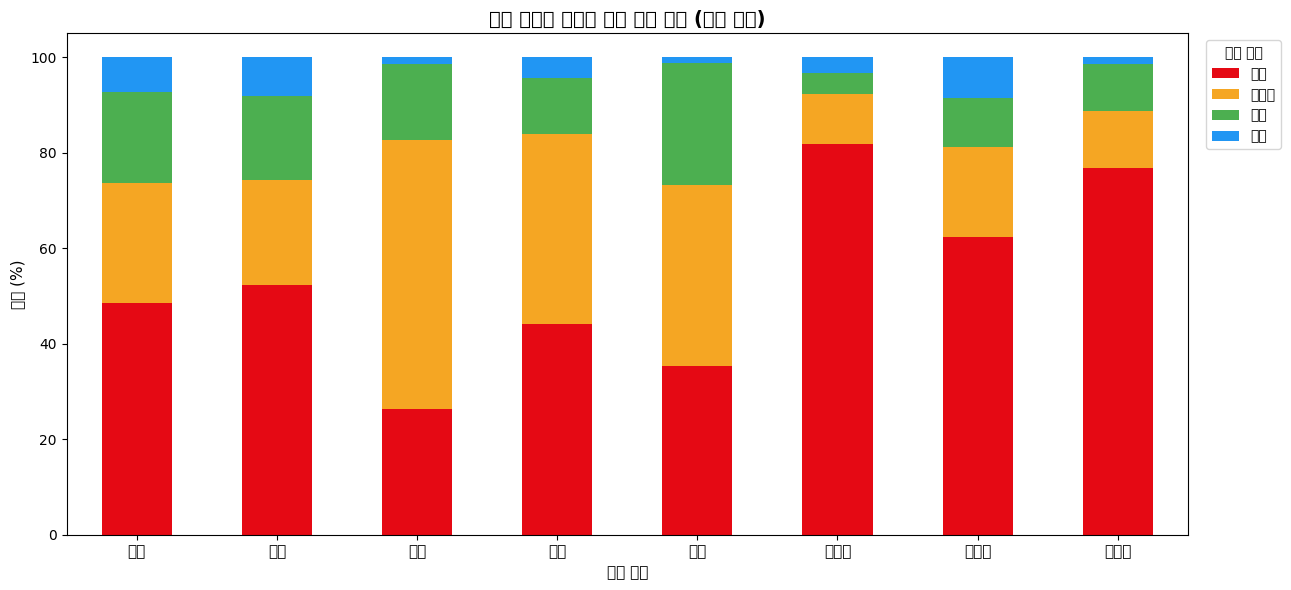


💡 팀 논의 인사이트:
  - 인도: 청소년 등급 비중 높음 → 10대 인구 비중(~65%) + 넷플릭스의 전략적 접근
  - 스페인/멕시코: 성인 콘텐츠 비중 높음 → 문화적 특성 반영
  - 미국 ≈ 영국, 한국 ≈ 일본 유사한 분포 패턴
  - ⚠ 현재 데이터는 '제작 국가' 기준 / '소비 국가' 데이터는 없음 → 추가 필요


In [11]:
# ─── 시각화 2: 국가별 콘텐츠 등급 편중 분석 ───
df_country = df_clean.dropna(subset=['country']).copy()
df_country['country_primary'] = df_country['country'].apply(lambda x: x.split(',')[0].strip())

rating_group = {
    'TV-MA': '성인', 'R': '성인', 'NC-17': '성인', 'NR': '성인', 'UR': '성인',
    'TV-14': '청소년', 'PG-13': '청소년',
    'TV-PG': '가족', 'PG': '가족', 'TV-Y7': '가족', 'TV-Y7-FV': '가족',
    'TV-Y': '아동', 'TV-G': '아동', 'G': '아동'
}
df_country['등급그룹'] = df_country['rating'].map(rating_group)

# 국가명 한글로 표시
country_label = {
    'United States': '미국', 'United Kingdom': '영국',
    'India': '인도', 'South Korea': '한국',
    'Japan': '일본', 'Spain': '스페인',
    'France': '프랑스', 'Mexico': '멕시코'
}
top_countries = list(country_label.keys())
df_top = df_country[df_country['country_primary'].isin(top_countries)].copy()
df_top['국가'] = df_top['country_primary'].map(country_label)

pivot = df_top.groupby(['국가', '등급그룹']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

order_kor = ['미국', '영국', '인도', '한국', '일본', '스페인', '프랑스', '멕시코']
pivot_pct = pivot_pct.reindex([c for c in order_kor if c in pivot_pct.index])

group_order = [g for g in ['성인', '청소년', '가족', '아동'] if g in pivot_pct.columns]
colors_group = {'성인': '#E50914', '청소년': '#F5A623', '가족': '#4CAF50', '아동': '#2196F3'}

pivot_pct[group_order].plot(
    kind='bar', stacked=True, figsize=(13, 6),
    color=[colors_group[c] for c in group_order]
)
plt.title('제작 국가별 콘텐츠 연령 등급 분포 (비율 기준)', fontsize=14, fontweight='bold')
plt.xlabel('제작 국가', fontsize=11)
plt.ylabel('비율 (%)', fontsize=11)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='등급 그룹', bbox_to_anchor=(1.01, 1), fontsize=10)
plt.tight_layout()
plt.show()

print("\n💡 팀 논의 인사이트:")
print("  - 인도: 청소년 등급 비중 높음 → 10대 인구 비중(~65%) + 넷플릭스의 전략적 접근")
print("  - 스페인/멕시코: 성인 콘텐츠 비중 높음 → 문화적 특성 반영")
print("  - 미국 ≈ 영국, 한국 ≈ 일본 유사한 분포 패턴")
print("  - ⚠ 현재 데이터는 '제작 국가' 기준 / '소비 국가' 데이터는 없음 → 추가 필요")

In [12]:
# ─── 기초 통계 요약 ───
print("=" * 55)
print("▶ 데이터 기본 현황")
print(f"  총 행 수   : {df.shape[0]:,}행")
print(f"  컬럼 수    : {df.shape[1]}개")
print(f"  유효 rating: {len(df_clean):,}건")
print()
print("▶ 콘텐츠 유형 분포")
for t, c in df['type'].value_counts().items():
    print(f"  {t}: {c:,}건 ({c/len(df)*100:.1f}%)")
print()
print("▶ 출시 연도 통계")
print(df[['release_year']].describe().round(1).to_string())
print()
print("🔴 최대 클래스 TV-MA: 36.4% — 불균형 데이터")

▶ 데이터 기본 현황
  총 행 수   : 8,807행
  컬럼 수    : 12개
  유효 rating: 8,800건

▶ 콘텐츠 유형 분포
  Movie: 6,131건 (69.6%)
  TV Show: 2,676건 (30.4%)

▶ 출시 연도 통계
       release_year
count        8807.0
mean         2014.2
std             8.8
min          1925.0
25%          2013.0
50%          2017.0
75%          2019.0
max          2021.0

🔴 최대 클래스 TV-MA: 36.4% — 불균형 데이터


### 데이터 현황 요약

```
행 수: 8,807  |  컬럼 수: 12
타깃(rating) 유효 데이터: 8,804건  |  클래스 수: 14개 (노이즈 3개 제거 시 11개)

최대 클래스 TV-MA : 3,207건 (36.4%)  ← 불균형 데이터
최소 클래스 NC-17 :     3건 ( 0.03%)  ← 극심한 희귀 등급
불균형 비율: 최대 1,069 : 1
```

**결측치 주의 컬럼**
- `director`: 29.9% 결측 → 피처 직접 사용 불가, 결측 여부 이진 피처로 변환
- `cast` / `country`: ~9.4% 결측 → 대표값 대체 또는 별도 처리

**listed_in 장르 파싱 필요**  
- 콤마 구분 멀티레이블 → 개별 장르로 분리 후 원핫인코딩 또는 빈도 기반 피처 생성  
- e.g. `"International TV Shows, TV Dramas, TV Mysteries"` → 3개 태그 분리

---
## 🔧 Section 3 — 접근법

---

### 🔷 [방법론]

#### ML 문제 유형
- **다중 분류 (Multi-class Classification)**
- 타깃: `rating` (14개 클래스 → 전처리 후 11개)

---

#### 주요 피처 후보 & 선택 근거

| 피처 | 유형 | 선택 근거 |
|------|------|-----------|
| `description` TF-IDF | 텍스트 | 줄거리 어휘가 등급 결정의 핵심 신호 |
| `title` TF-IDF | 텍스트 | 제목에 장르/분위기 단서 포함 |
| `listed_in` OHE | 카테고리 | 장르와 등급 간 강한 상관관계 |
| `type` | 이진 | Movie vs TV Show별 등급 분포 상이 |
| `country_primary` | 카테고리 | 국가별 심의 기준 차이 반영 |
| `release_year` | 수치 | 시대별 등급 기준 변화 트렌드 |
| `director_missing` | 이진 | 결측 여부 → 콘텐츠 유형 시그널 |
| `genre_count` | 수치 | 장르 태그 수 → 콘텐츠 복잡도 |

---

#### 불균형 처리 전략 (핵심)

> 📌 **"불균형 데이터를 어떻게 다뤘는가"**가 이 프로젝트의 차별점이다.  
> 아래 4단계 파이프라인을 적용하여 소수 클래스 탐지력을 극대화한다.

```
Step 1. class_weight='balanced'
         → 모델 학습 시 소수 클래스에 높은 가중치 부여 (빠르고 효과적)

Step 2. SMOTE — Pipeline 내부에서만 적용
         → Train fold에만 오버샘플링, Test/Val 데이터 누수 방지
         → Pipeline: [SMOTE → StandardScaler → XGBoost]

Step 3. Threshold Tuning
         → 비용 매트릭스 기반으로 클래스별 최적 임계치 조정
         → 성인 콘텐츠 오분류(FN) 비용 > 과도 분류(FP) 비용
         → TV-MA threshold: 기본 0.5 → 0.35로 낮춰 Recall 우선

Step 4. Isotonic Calibration
         → 모델 확률값 보정, 비즈니스 threshold 적용 신뢰도 향상
         → CalibratedClassifierCV(method='isotonic')
```

---

#### 모델 전략

| 단계 | 모델 | 역할 |
|------|------|------|
| **Baseline** | Logistic Regression (TF-IDF) | 텍스트 분류 빠른 벤치마크 |
| **모델 1** | Random Forest + Genre OHE | 피처 중요도 해석 |
| **모델 2 (메인)** | **XGBoost** + class_weight + Calibration | 최종 성능 목표 모델 |
| **검증** | Stratified 5-Fold CV | 클래스 비율 유지한 교차 검증 |

---

#### Reference Notebook에서 배운 점 & 적용 계획

- **SMOTE는 반드시 Pipeline 안에서** — Train fold에서만 적용, Val에는 원본 사용
- **Accuracy는 불균형 지표로 부적합** → Macro F1 + PR-AUC를 주 메트릭으로
- **Threshold는 모델러가 아니라 비즈니스가 정한다** — 비용 매트릭스 설계 후 최적화

In [15]:
# ─── 베이스라인 파이프라인 구조 스케치 ───
# 실제 학습은 분석 노트북(4/11 제출)에서 수행
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# 피처 엔지니어링
df_feat = df_clean.copy()
df_feat['text_combined'] = (
    df_feat['title'].fillna('') + ' ' +
    df_feat['description'].fillna('') + ' ' +
    df_feat['listed_in'].fillna('')
)
df_feat['genre_count']      = df_feat['listed_in'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
df_feat['director_missing'] = df_feat['director'].isnull().astype(int)
df_feat['country_primary']  = df_feat['country'].apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)

print("▶ 피처 엔지니어링 완료")
print(f"  text_combined 샘플: {df_feat['text_combined'].iloc[0][:80]}...")
print(f"  genre_count 평균  : {df_feat['genre_count'].mean():.1f}개")
print(f"  director 결측 수  : {df_feat['director_missing'].sum():,}건 ({df_feat['director_missing'].mean()*100:.1f}%)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n▶ 검증 전략: Stratified 5-Fold (seed=42)")

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
print("▶ Baseline Pipeline 구성:", list(baseline_pipeline.named_steps.keys()))

▶ 피처 엔지니어링 완료
  text_combined 샘플: Dick Johnson Is Dead As her father nears the end of his life, filmmaker Kirsten ...
  genre_count 평균  : 2.2개
  director 결측 수  : 2,631건 (29.9%)

▶ 검증 전략: Stratified 5-Fold (seed=42)
▶ Baseline Pipeline 구성: ['tfidf', 'clf']


---
## 🎯 Section 4 — 기대 결과 & 리스크

---

### 🔷 [성과] — 예상 목표

#### 비즈니스 지표

| 시나리오 | 수동 분류 | 자동 분류 (모델) | 절감 효과 |
|---------|-----------|-----------------|----------|
| 월 신규 콘텐츠 500건 처리 | 인력 3명 × 5시간/건 | 고위험 20%만 수동 검토 | **인력 비용 약 60% 절감** |
| 잘못된 성인 등급 노출 | 규제 리스크 高 | Recall ≥ 0.78 → 탐지율 향상 | **규제 제재 리스크 감소** |

#### 핵심 기술 지표 (예상)

| 메트릭 | Baseline (LR) | 목표 (XGBoost+Cal.) |
|--------|--------------|--------------------|
| Macro F1 | ~0.52 | **≥ 0.65** |
| Weighted Recall | ~0.65 | **≥ 0.72** |
| ROC-AUC (OvR) | ~0.80 | **≥ 0.85** |

#### 권장 Threshold & 비용 매트릭스

```
비용 매트릭스 설계:
  - FN (Adult 등급 → 낮게 예측): 비용 HIGH — 아동 노출, 규제 제재
  - FP (Family 등급 → 높게 예측): 비용 LOW  — 구독자 불편, 콘텐츠 제한

→ TV-MA 클래스 threshold: 기본 0.5 → 0.35로 낮춰 Recall 우선
→ Isotonic Calibration으로 확률 보정 후 threshold 적용
```

---

### 🔷 [리스크 & 다음 단계]

#### 주요 리스크

| 리스크 | 심각도 | 대응 방안 |
|--------|--------|----------|
| `director` 30% 결측 | 중 | 결측 여부 이진 피처 + 나머지 피처로 보완 |
| NC-17·UR 클래스 3건 | 높 | 유사 등급 병합 또는 제외 후 재분류 |
| 다국어 설명문 혼재 | 중 | langdetect 필터링 또는 다국어 임베딩 |
| TF-IDF 고차원 과적합 | 중 | max_features 조정 + L2 정규화 |
| 2021년 이전 데이터 | 낮 | 최신 트렌드 반영 불가 — 한계점 명시 |
| 소비 국가 데이터 없음 | 중 | 외부 데이터 결합 검토 |

#### 데이터 품질 점검 8문항

| # | 항목 | 결과 |
|---|------|------|
| 1 | 결측치 5% 이상 컬럼 개수 | **1개** (director 29.9%) |
| 2 | 중복 행 존재 여부 | show_id 기준 확인 필요 |
| 3 | 타깃 분포 | TV-MA 36.4% / TV-14 24.5% — **불균형** |
| 4 | 수치형 / 범주형 컬럼 수 | 수치형 1개 / 범주형 11개 |
| 5 | 시점 정보 | **Y** — date_added, release_year 존재 |
| 6 | 피처 간 Leakage 의심 항목 | **없음** (rating은 콘텐츠 메타 기반) |
| 7 | 학습 시간 예상 | 8,807행 소규모 → **로컬 5분 이내** |
| 8 | 라이선스 / 공유 제약 | **CC0 Public Domain** (Kaggle 공개) |

#### 비즈니스 질문 Top 3 & 메인 질문

| | 질문 |
|-|------|
| **Q1** | 제목·줄거리·장르 텍스트만으로 콘텐츠 연령 등급을 자동 예측할 수 있는가? |
| **Q2** | 국가별 콘텐츠 등급 분포는 유의미하게 다르며, 그 차이는 문화·인구통계로 설명되는가? |
| **Q3** | 넷플릭스는 연도별로 어떤 장르와 콘텐츠 유형에 집중해왔으며, 전략 변화가 데이터로 확인되는가? |
| 🎯 **메인** | **"텍스트(제목·줄거리·장르)만으로 콘텐츠 연령 등급을 자동 분류할 수 있는가?"** — ML 모델링·NLP·비즈니스 가치가 가장 긴밀하게 연결되어 분석 스토리텔링 구성이 풍부하기 때문 |

#### 6주차까지 작업 타임라인

```
Week 1-2 (완료)   : 데이터 이해 & 기획안 작성
Week 3-4 (4/11)   : EDA → Feature Engineering → Baseline → XGBoost + SMOTE Pipeline
Week 5            : Threshold Tuning + Calibration + 추천 시스템 프로토타입
Week 6            : Kaggle 제출 & 리더보드 + 비즈니스 인사이트 스토리텔링 + 발표
```

---

### 핵심 요약 (3줄)

1. **함정**: 정확도만 보면 속는다 — TV-MA만 예측해도 Acc 36%, Macro F1로 평가해야 진짜 성능을 안다.
2. **무기**: `class_weight` → SMOTE(Pipeline 내) → Threshold Tuning → Isotonic Calibration → Stratified K-Fold, 이 순서가 디버깅 가능한 안전한 길이다.
3. **So What**: 모델 출력을 비용/규제/운영 절감의 비즈니스 언어로 번역해야 1-Pager가 살아난다 — Threshold는 모델러가 아니라 비즈니스가 정한다.